# Разведочный анализ данных. Исследование и визуализация данных.

## 1) Текстовое описание набора данных

В качестве набора данных мы будем использовать набор данных по обнаружению проблем с сердцем
https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

Данная задача является очень популярной в сфере медицины и данный датасет может быть использован для обнаружения групп лиц. подверженных риску или уже имеющих сердечные заболевания.
Датасет состоит из файла:
- heart.csv - Файл, являющийся комбинацией пяти других датасетов, хранящих записи о реальных пациентах:
    - Cleveland: 303 записи
    - Hungarian: 294 записи
    - Switzerland: 123 записи
    - Long Beach VA: 200 записи
    - Stalog (Heart) Data Set: 270 записи

Итого: 1190 записи
Дублированных: 272 записи
Итоговый датасет: 918 записи

Каждый файл содержит следующие аттрибуты:
1. Age: возраст пациента [years]
2. Sex: пол пациента [M: Male, F: Female]
3. ChestPainType: тип грудной боли [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
4. RestingBP: давление в спокойном состоянии [mm Hg]
5. Cholesterol: уровень холестерина [mm/dl]
6. FastingBS: сахар в крови натощак [1: if FastingBS > 120 mg/dl, 0: otherwise]
7. RestingECG: результаты ЭКГ в спокойном состянии [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
8. MaxHR: максимальная скорость сердцебьения [Numeric value between 60 and 202]
9. ExerciseAngina: стенокардия после упражнений [Y: Yes, N: No]
10. Oldpeak: значение упадка сегмента ST на ЭКГ [Numeric value measured in depression]
11. ST_Slope: тип склона векршины сегмента ST на ЭКГ [Up: upsloping, Flat: flat, Down: downsloping]
12. HeartDisease: Есть ли заболевание. Целевой признак. [1: heart disease, 0: Normal]

### Импорт Библиотек

In [14]:
try:
    import numpy as np
except:
    !pip install numpy
    import numpy as np

try:
    import pandas as pd
except:
    !pip install pandas
    import pandas as pd

try:
    import seaborn as sns
except:
    !pip install seaborn
    import seaborn as sns

try:
    import matplotlib.pyplot as plt
except:
    !pip install matplotlib
    import matplotlib.pyplot as plt

try:
    import kagglehub
except:
    !pip install kagglehub
    import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")


### Загрузка данных

In [17]:
data = pd.read_csv(path+'/heart.csv')

## 2) Основные характеристики датасета

In [20]:
# Первые 5 строк датасета
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [22]:
# Размер датасета - 918 строк, 12 колонок
data.shape

(918, 12)

In [24]:
# Список колонок с типами данных
data.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [26]:
# Проверим наличие пустых значений
# Цикл по колонкам датасета
for col in data.columns:
    # Количество пустых значений - все значения заполнены
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

Age - 0
Sex - 0
ChestPainType - 0
RestingBP - 0
Cholesterol - 0
FastingBS - 0
RestingECG - 0
MaxHR - 0
ExerciseAngina - 0
Oldpeak - 0
ST_Slope - 0
HeartDisease - 0


In [28]:
# Основные статистические характеристки набора данных
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [38]:
# Определим уникальные значения для целевого признака
unique_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in unique_cols:
    print("{}: {}".format(col, list(data[col].unique())))

Sex: ['M', 'F']
ChestPainType: ['ATA', 'NAP', 'ASY', 'TA']
RestingECG: ['Normal', 'ST', 'LVH']
ExerciseAngina: ['N', 'Y']
ST_Slope: ['Up', 'Flat', 'Down']


Целевой признак является бинарным и содержит только значения 0 и 1.

## 3) Визуальное исследование датасета

### Диаграмма рассеяния

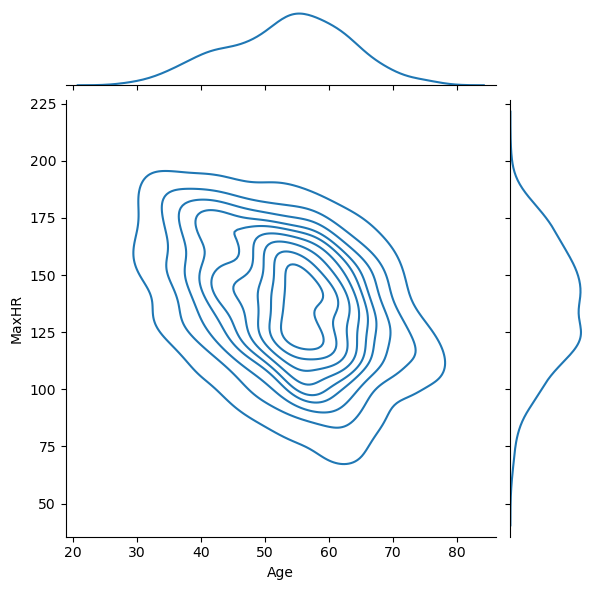

In [99]:

sns.jointplot(x='Age', y='MaxHR', data=data, kind="kde")

Можно увидить, что есть тренд уменьшения максимальной частоты сердцебьения с возрастом.

Посмотрим насколько на эту зависимость влияет целевой признак.

<Axes: xlabel='Age', ylabel='MaxHR'>

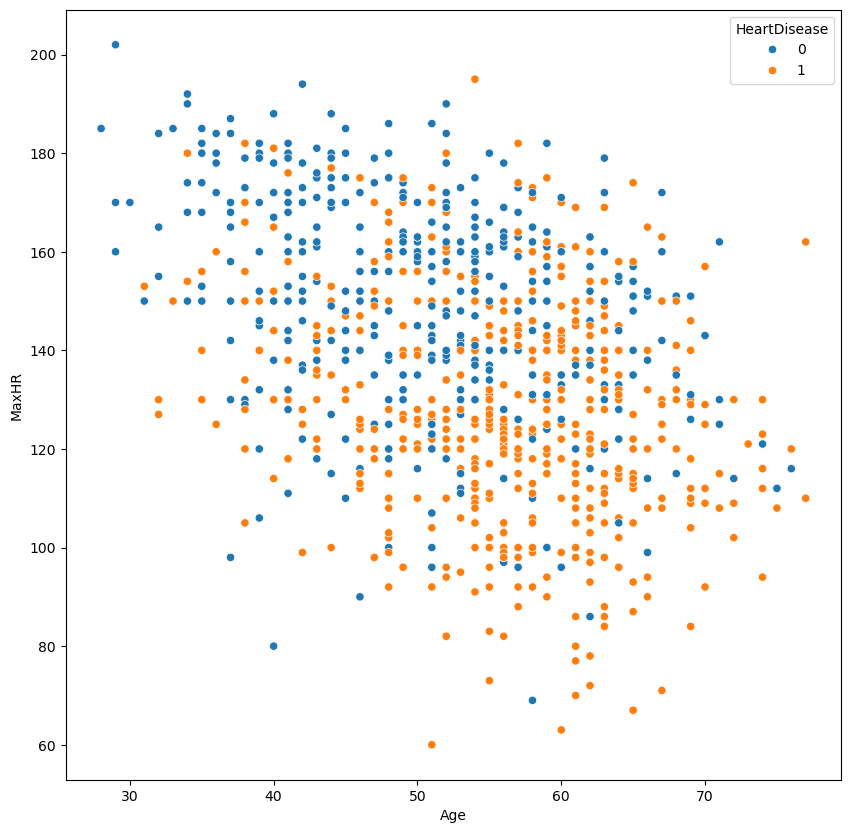

In [62]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='Age', y='MaxHR', data=data, hue="HeartDisease")

### Парные диаграммы

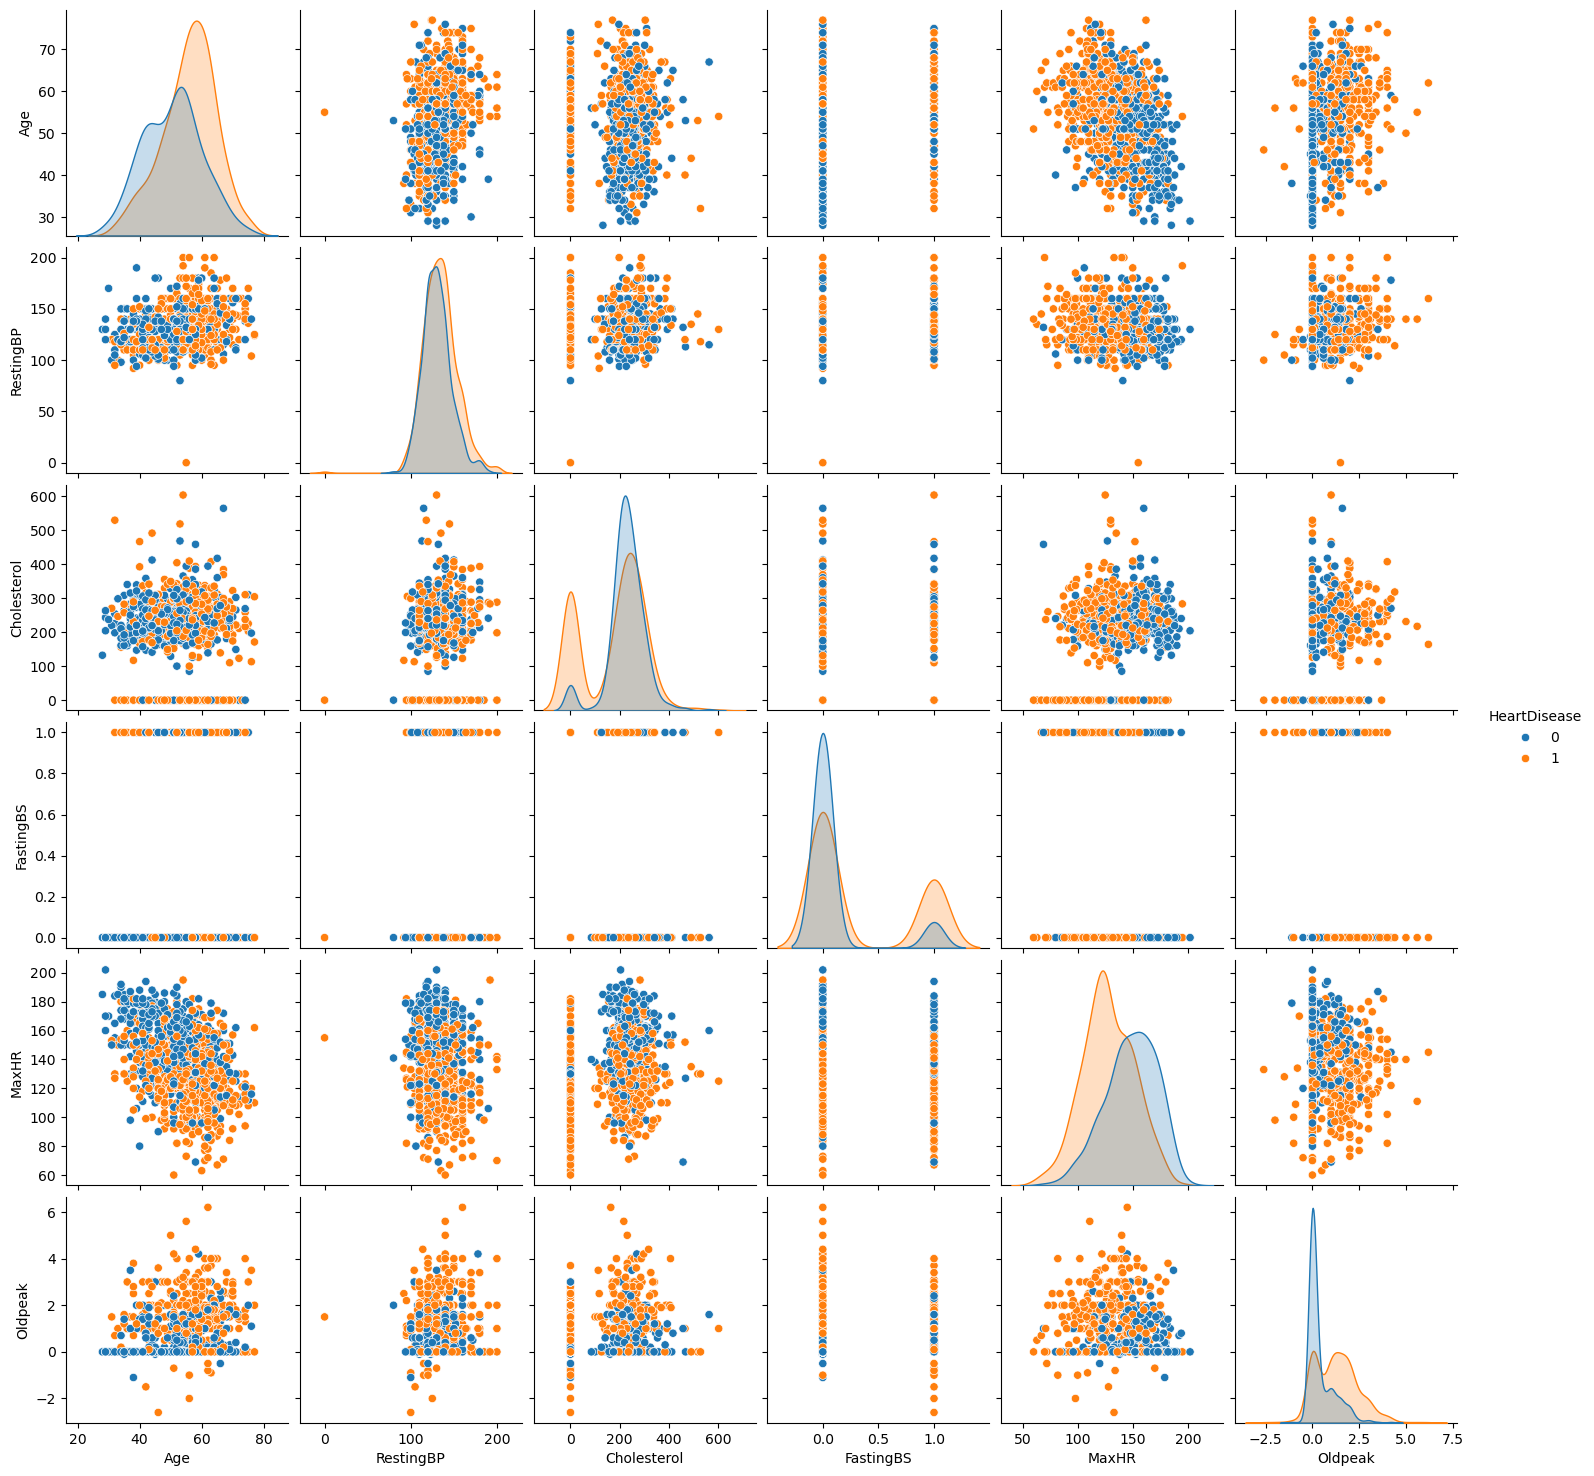

In [83]:
sns.pairplot(data, hue="HeartDisease")

## 4) Информация о корреляции признаков

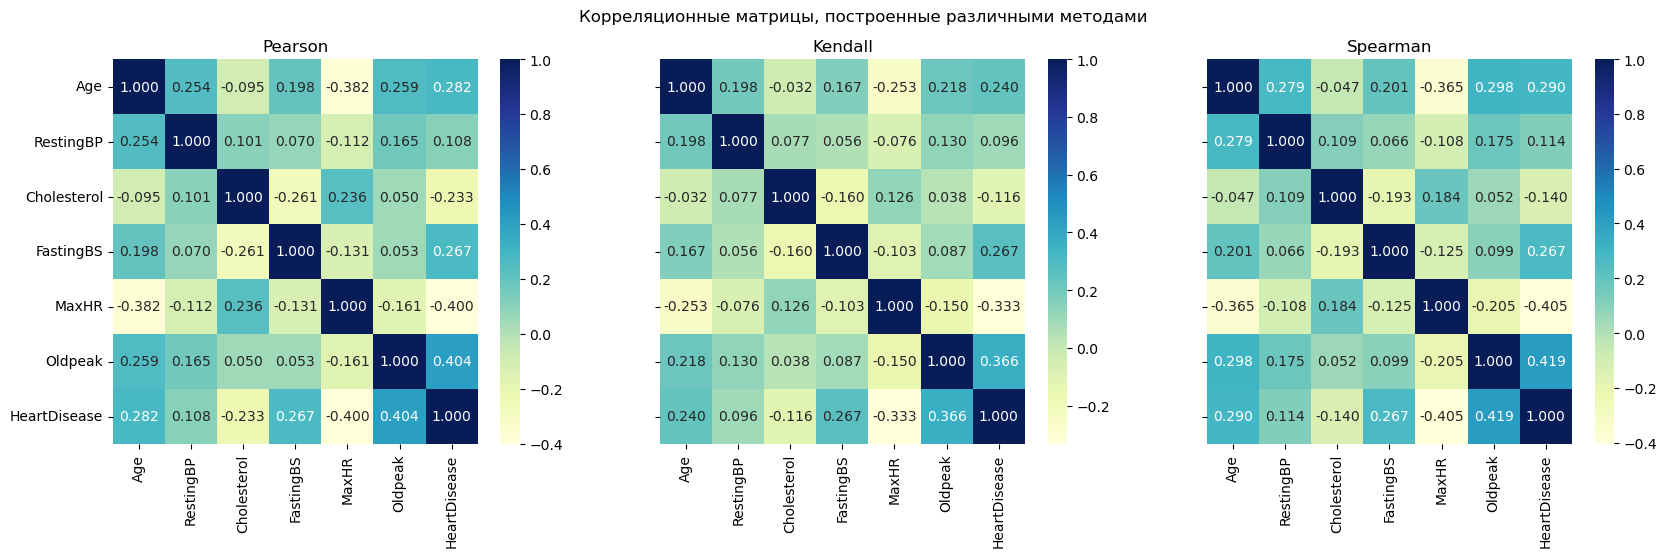

In [119]:


fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(20,5))
sns.heatmap(data.corr(method='pearson', numeric_only=True), ax=ax[0], annot=True, fmt='.3f', cmap='YlGnBu')
sns.heatmap(data.corr(method='kendall', numeric_only=True), ax=ax[1], annot=True, fmt='.3f', cmap='YlGnBu')
sns.heatmap(data.corr(method='spearman', numeric_only=True), ax=ax[2], annot=True, fmt='.3f', cmap='YlGnBu')
fig.suptitle('Корреляционные матрицы, построенные различными методами')
ax[0].title.set_text('Pearson')
ax[1].title.set_text('Kendall')
ax[2].title.set_text('Spearman')